In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

print("Libraries loaded as expected")

Libraries loaded as expected


In [53]:
df = pd.read_csv("Planetary_data.csv", comment="#")

In [35]:
# Planets in goldilocks zone.
## Planets with planet_radius < 1.5 and planet_equilibrium temperature in between 250 and 350 kelvin.

subset_data = df.dropna(subset=['pl_eqt', 'pl_rade'])
planets_with_earth_like_rade = subset_data[
    (subset_data['pl_rade'] < 1.5) &
    (subset_data['pl_eqt'].between(250, 350, inclusive='neither'))
][
    ['pl_name', 'pl_rade', 'pl_eqt', 'sy_dist']
  ]

final_data = planets_with_earth_like_rade.sort_values(by=['pl_rade', 'pl_eqt'], ascending=[False, False]).head(10)
print(final_data)

            pl_name  pl_rade  pl_eqt     sy_dist
4893      L 98-59 e    1.490  347.00   10.619400
4894      L 98-59 f    1.480  285.00   10.619400
1706         K2-3 d    1.458  305.20   44.072700
291        GJ 411 b    1.450  349.83    5.675773
2315  Kepler-1126 c    1.450  305.00  635.736000
217       GJ 1132 c    1.430  300.00   12.613000
4915     LP 890-9 c    1.367  272.00   32.429800
2761  Kepler-1459 b    1.360  349.00  455.479000
3549   Kepler-220 e    1.330  341.00  171.109000
5483     TOI-2095 c    1.330  297.00   41.917600


In [40]:
## planet closest to Earth.

close_to_earth = final_data.sort_values(by='sy_dist', ascending=True)
print(close_to_earth.head(5))

         pl_name  pl_rade  pl_eqt    sy_dist
291     GJ 411 b    1.450  349.83   5.675773
4893   L 98-59 e    1.490  347.00  10.619400
4894   L 98-59 f    1.480  285.00  10.619400
217    GJ 1132 c    1.430  300.00  12.613000
4915  LP 890-9 c    1.367  272.00  32.429800


In [47]:
disc_per_year = df['disc_year'].value_counts().sort_index()
print(disc_per_year.sort_values(ascending=False).head(10))

disc_year
2016.0    1496
2014.0     869
2021.0     564
2022.0     368
2023.0     323
2018.0     315
2024.0     259
2025.0     245
2020.0     235
2026.0     200
Name: count, dtype: int64


<Axes: title={'center': 'Planets discovered per year'}, xlabel='disc_year'>

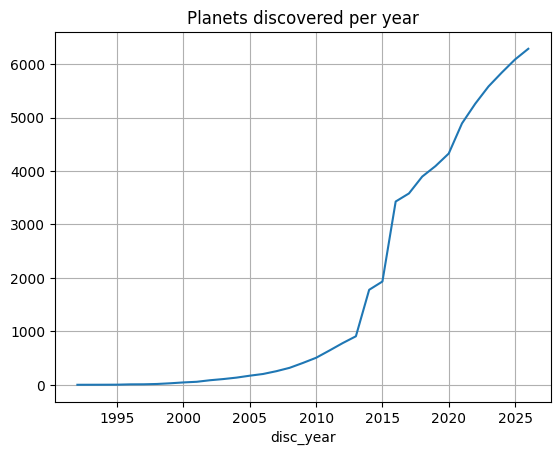

In [49]:
## Total planets discovered per year.

total_planets_per_year = disc_per_year.cumsum()
total_planets_per_year.plot(kind='line', title="Planets discovered per year", grid=True)

In [54]:
## top methods

top_methods = df[df['discoverymethod'].isin(['Transit', 'Radial Velocity'])]
method_timeline = pd.crosstab(top_methods['disc_year'], top_methods['discoverymethod'])
print(method_timeline.head(5))

discoverymethod  Radial Velocity  Transit
disc_year                                
1995.0                         1        0
1996.0                         6        0
1997.0                         1        0
1998.0                         6        0
1999.0                        13        0


<Axes: title={'center': 'Distribution of Transit vs Radial Velocity methods'}, xlabel='disc_year'>

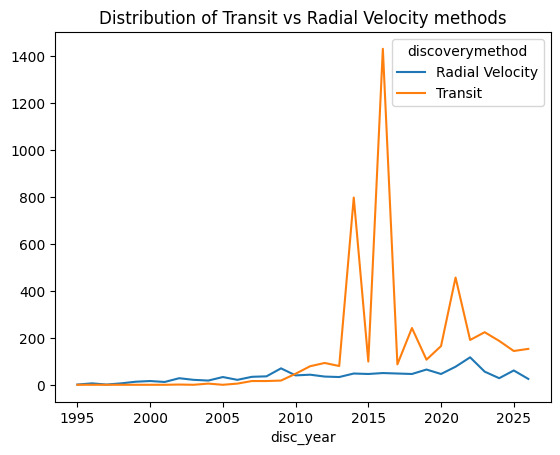

In [52]:
# Radial velocity: Old school method of detecting exoplanets. Watching star wobble because heavy planet is pulling on them.
# Transit : New method of detecting exoplanets. Watching star dim slightly when a planet crosses in front of it.

method_timeline.plot(kind='line', title="Distribution of Transit vs Radial Velocity methods")